In [ ]:
import zipfile
zip_ref=zipfile.ZipFile('/content/dataset.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import tensorflow
from tensorflow import keras
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense,Dropout,MaxPool2D,Conv2D,Flatten,BatchNormalization
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


In [ ]:
#GENRATORS Divide data into batches
Trian_DS=keras.utils.image_dataset_from_directory(directory='/content/dataset/training_set',
                                                  labels='inferred',
                                                  label_mode='int',
                                                  batch_size=32,
                                                  image_size=(256,256))
Test_DS=keras.utils.image_dataset_from_directory('/content/dataset/test_set',
                                                  labels='inferred',
                                                  label_mode='int',
                                                  batch_size=32,
                                                  image_size=(256,256))

Found 8000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [ ]:
#Normaliztion
def process(image,label):
  image=tensorflow.cast(image/255.0,tensorflow.float32)
  return image,label
Trian_DS=Trian_DS.map(process)
Test_DS=Test_DS.map(process)


In [ ]:
#ARCHITECTURE

model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,733,217 (14.24 MB)

 Trainable params: 3,732,961 (14.24 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

250*32=8000

In [ ]:
callback=EarlyStopping(min_delta=0.001,monitor='val_accuracy',patience=3)

In [ ]:
history=model.fit(Trian_DS,epochs=10,validation_data=Test_DS,callbacks=callback)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 87ms/step - accuracy: 0.5309 - loss: 1.4098 - val_accuracy: 0.5450 - val_loss: 0.9216
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.5271 - loss: 0.7088 - val_accuracy: 0.5870 - val_loss: 0.6466
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.5410 - loss: 0.6987 - val_accuracy: 0.5380 - val_loss: 0.6699
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.5551 - loss: 0.7240 - val_accuracy: 0.5730 - val_loss: 0.6774
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.5707 - loss: 0.6853 - val_accuracy: 0.6190 - val_loss: 0.6342
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.5751 - loss: 0.6693 - val_accuracy: 0.5870 - val_loss: 0.7824
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.5944 - loss: 0.6584 - val_accuracy: 0.5605 - val_loss: 0.6661
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.6348 - loss: 0.6281 - 

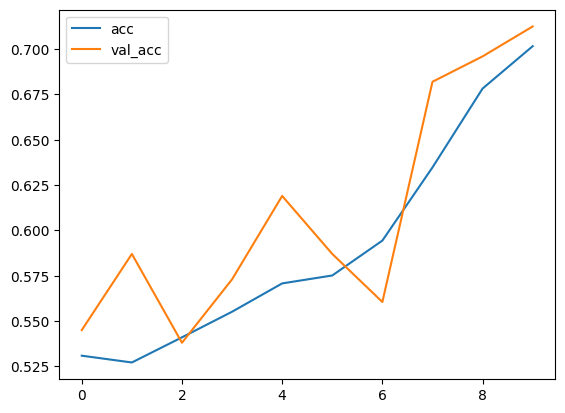

In [ ]:
plt.plot(history.history['accuracy'],label='acc')
plt.plot(history.history['val_accuracy'],label='val_acc')
plt.legend()

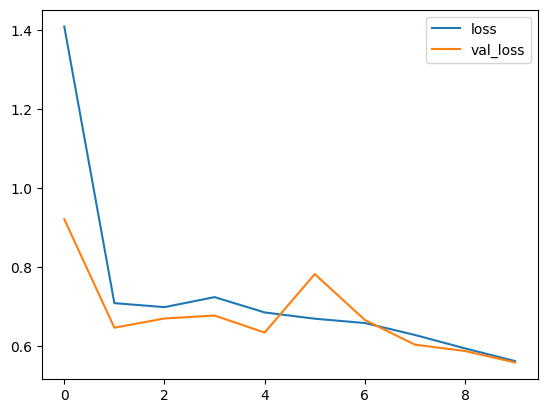

In [ ]:
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()

In [ ]:
import cv2

(256, 256, 3)


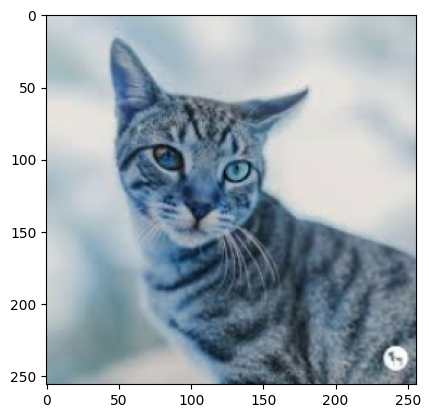

In [ ]:
imag1=cv2.imread('/content/download (16).jpeg')
imag1=cv2.resize(imag1,(256,256))
plt.imshow(imag1)
print(imag1.shape)

In [ ]:

imag1=imag1.reshape((1,256,256,3))
print(model.predict(imag1))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.26625186]]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
batch_size=16
datagen_train=ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

In [ ]:
datagen_test=ImageDataGenerator(
    rescale=1./255,
)

In [ ]:
Trian_DS=datagen_train.flow_from_directory(directory='/content/dataset/training_set',

                                                  batch_size=32,
                                                  target_size=(256,256),class_mode='binary')
Test_DS=datagen_test.flow_from_directory('/content/dataset/test_set',

                                                  batch_size=32,
                                                  target_size=(256,256),

                                                  class_mode='binary' )

Found 8000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


In [ ]:
#ARCHITECTURE

model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(Trian_DS,epochs=10,validation_data=Test_DS,callbacks=callback)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 135s 514ms/step - accuracy: 0.5312 - loss: 1.6057 - val_accuracy: 0.5085 - val_loss: 0.9722
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 126s 502ms/step - accuracy: 0.5230 - loss: 0.7179 - val_accuracy: 0.5235 - val_loss: 0.8385
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 126s 502ms/step - accuracy: 0.5404 - loss: 0.6971 - val_accuracy: 0.5365 - val_loss: 0.6774
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 126s 505ms/step - accuracy: 0.5458 - loss: 0.6939 - val_accuracy: 0.5660 - val_loss: 0.6678
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 127s 508ms/step - accuracy: 0.5569 - loss: 0.6852 - val_accuracy: 0.6490 - val_loss: 0.6371
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 126s 505ms/step - accuracy: 0.5781 - loss: 0.6674 - val_accuracy: 0.6495 - val_loss: 0.6249
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 127s 508ms/step - accuracy: 0.5723 - loss: 0.6882 - val_accuracy: 0.5195 - val_loss: 0.9605
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 129s 517ms/step - accuracy: 0.6001 -